In [1]:
import pandas as pd
import numpy as np

In [2]:
import statsmodels.api as sm 
from statsmodels.formula.api import ols
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
import statsmodels.formula.api as smf

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

In [5]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'

In [6]:
df = pd.read_excel(fpath + '\\4.0_database_variables.xlsx')

In [7]:
df = df.rename(columns={'location(ita=0,uk=1,usa=2)': 'location', 'week(1=free days)': 'weekday_type'})

In [8]:
# remove outliers
df = df[(np.abs(stats.zscore(df['sleep_duration(h)'])) < 3)]
df = df[(np.abs(stats.zscore(df['midpoint_h'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) < 3)]

In [9]:
df = df.drop('sunrise_time(USA)', axis=1)
df = df.drop('sunrise (USA), hours', axis=1)
df = df.drop('sunset (USA), hours', axis=1)
df = df.drop('sunset_time(USA)', axis=1)
df = df.drop('photoperiod (h, USA)', axis=1)

In [10]:
# Define the start date
start_date = pd.to_datetime('2022-09-21')

In [11]:
# Function to calculate the week of the year from the start date
def calculate_week_of_year(date):
    year_diff = date.year - start_date.year
    start_of_year = pd.to_datetime(f'{date.year}-01-01')
    weeks_from_start = ((date - start_of_year).days // 7) + 1
    return year_diff * 52 + weeks_from_start

# Apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [12]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [13]:
# rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df['weekday_type'] = df['weekday_type'].map({0: 'work days', 1: 'free days'})

# EDA

In [14]:
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

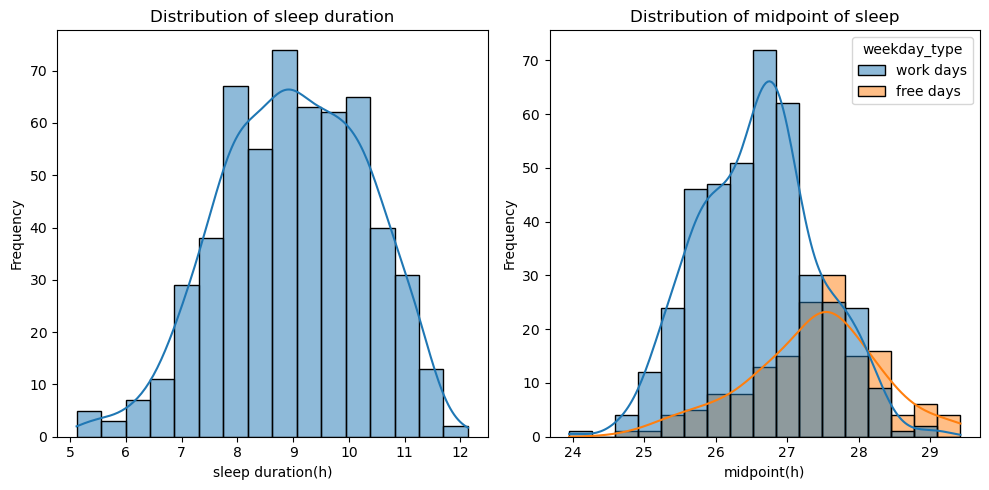

In [15]:
# Distribution 
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['sleep_duration(h)'].dropna(), kde=True)
plt.title("Distribution of sleep duration")
plt.xlabel("sleep duration(h)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='midpoint_h', hue='weekday_type', kde=True)
plt.title("Distribution of midpoint of sleep")
plt.xlabel("midpoint(h)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

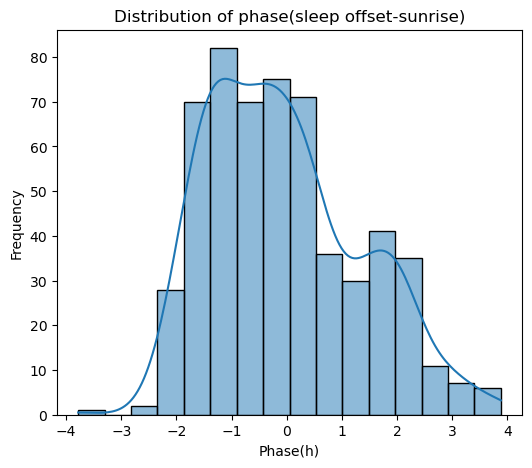

In [16]:
# Distribution 
plt.figure(figsize=(6, 5))
sns.histplot(df['phase(sleepoffset-sunrise)'].dropna(), kde=True)
plt.title("Distribution of phase(sleep offset-sunrise)")
plt.xlabel("Phase(h)")
plt.ylabel("Frequency")
plt.show()

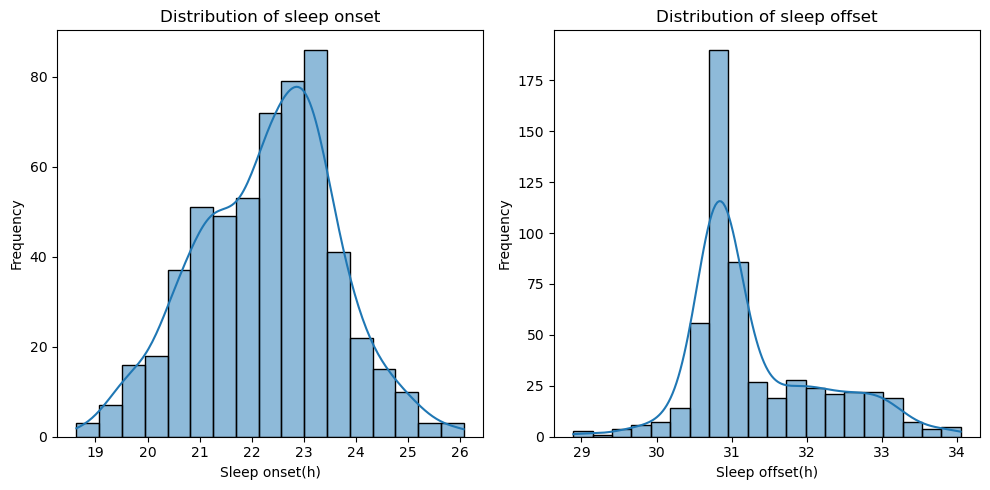

In [17]:
# Distribution 
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['sleep_start_decimal'].dropna(), kde=True)
plt.title("Distribution of sleep onset")
plt.xlabel("Sleep onset(h)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(df['sleep_end_decimal'].dropna(), kde=True)
plt.title("Distribution of sleep offset")
plt.xlabel("Sleep offset(h)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [18]:
# test normality of the data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration(h)'])
shapiro_test_midpoint = stats.shapiro(df['midpoint_h'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal'])
shapiro_test_phase = stats.shapiro(df['phase(sleepoffset-sunrise)'])

In [19]:
shapiro_results_descriptive = pd.DataFrame({
    'Variable': ['sleep_duration(h)', 'midpoint_h', 'sleep_start_decimal', 'sleep_end_decimal', 'phase(sleepoffset-sunrise)'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_midpoint, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase]
})

In [20]:
shapiro_results_descriptive

,Variable,Shapiro-Wilk test
0,sleep_duration(h),"(0.9902568788231293, 0.0008572700408180585)"
1,midpoint_h,"(0.9953842221350677, 0.09176026856174113)"
2,sleep_start_decimal,"(0.9933031110054771, 0.012890058203709061)"
3,sleep_end_decimal,"(0.8910493382471318, 1.4676570099459215e-19)"
4,phase(sleepoffset-sunrise),"(0.9644101411394511, 1.8415611196210638e-10)"


In [21]:
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [22]:
df_grouped_weekday = df.groupby('weekday_type').describe()
df_grouped_weekday = df_grouped_weekday.transpose()

In [23]:
df_grouped_location_weekday = df.groupby(['location', 'weekday_type']).describe()
df_grouped_location_weekday = df_grouped_location_weekday.transpose()

In [24]:
# filtered the midpoints by week days
df_workdays = df[df['weekday_type'] == 'work days']
df_freedays = df[df['weekday_type'] == 'free days']

In [25]:
# compare the midpoint, duration and phase between the two locations
ttest_midpoint_workdays_loc = stats.ttest_ind(df_workdays[df_workdays['location'] == 'ITA']['midpoint_h'], df_workdays[df_workdays['location'] == 'UK']['midpoint_h'])
ttest_midpoint_freedays_loc = stats.ttest_ind(df_freedays[df_freedays['location'] == 'ITA']['midpoint_h'], df_freedays[df_freedays['location'] == 'UK']['midpoint_h'])
utest_duration_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_duration(h)'], df[df['location'] == 'UK']['sleep_duration(h)'])
utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase(sleepoffset-sunrise)'], df[df['location'] == 'UK']['phase(sleepoffset-sunrise)'])
utest_start_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_start_decimal'], df[df['location'] == 'UK']['sleep_start_decimal'])
utest_end_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_end_decimal'], df[df['location'] == 'UK']['sleep_end_decimal'])

# compare the midpoint, duration and phase between work days and free days
ttest_midpoint_week = stats.ttest_ind(df[df['weekday_type'] == 'work days']['midpoint_h'], df[df['weekday_type'] == 'free days']['midpoint_h'])
utest_duration_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_duration(h)'], df[df['weekday_type'] == 'free days']['sleep_duration(h)'])
utest_phase_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['phase(sleepoffset-sunrise)'], df[df['weekday_type'] == 'free days']['phase(sleepoffset-sunrise)'])
utest_start_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_start_decimal'], df[df['weekday_type'] == 'free days']['sleep_start_decimal'])
utest_end_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_end_decimal'], df[df['weekday_type'] == 'free days']['sleep_end_decimal'])

In [26]:
print('T test results for location')
print('Midpoint_work:', ttest_midpoint_workdays_loc)
print('Midpoint_free:', ttest_midpoint_freedays_loc)
print('U test results for location')
print('Sleep_onset:', utest_start_loc)
print('Sleep_offset:', utest_end_loc)
print('Sleep_duration:', utest_duration_loc)
print('Phase:', utest_phase_loc)

T test results for location
Midpoint_work: TtestResult(statistic=3.2479858746178083, pvalue=0.0012583768691001595, df=408.0)
Midpoint_free: TtestResult(statistic=-0.028649054617328643, pvalue=0.9771818234370077, df=153.0)
U test results for location
Sleep_onset: MannwhitneyuResult(statistic=43086.0, pvalue=0.016744036620543745)
Sleep_offset: MannwhitneyuResult(statistic=44214.5, pvalue=0.0028419870319967523)
Sleep_duration: MannwhitneyuResult(statistic=37319.5, pvalue=0.5273231488217915)
Phase: MannwhitneyuResult(statistic=23106.0, pvalue=6.067805061758257e-16)


In [27]:
print('T test results for free/work days:') 
print('Midpoint:', ttest_midpoint_week)
print('U test results for free/work days:')
print('Sleep_onset:', utest_start_week)
print('Sleep_offset:', utest_end_week)
print('Sleep_duration:', utest_duration_week)
print('Phase:', utest_phase_week)

T test results for free/work days:
Midpoint: TtestResult(statistic=-9.50032089200523, pvalue=5.939401753000896e-20, df=563.0)
U test results for free/work days:
Sleep_onset: MannwhitneyuResult(statistic=24237.0, pvalue=1.3387708775414803e-05)
Sleep_offset: MannwhitneyuResult(statistic=13908.5, pvalue=5.7403258442340225e-25)
Sleep_duration: MannwhitneyuResult(statistic=26278.5, pvalue=0.0015010629524126338)
Phase: MannwhitneyuResult(statistic=19999.5, pvalue=1.037493960895366e-11)


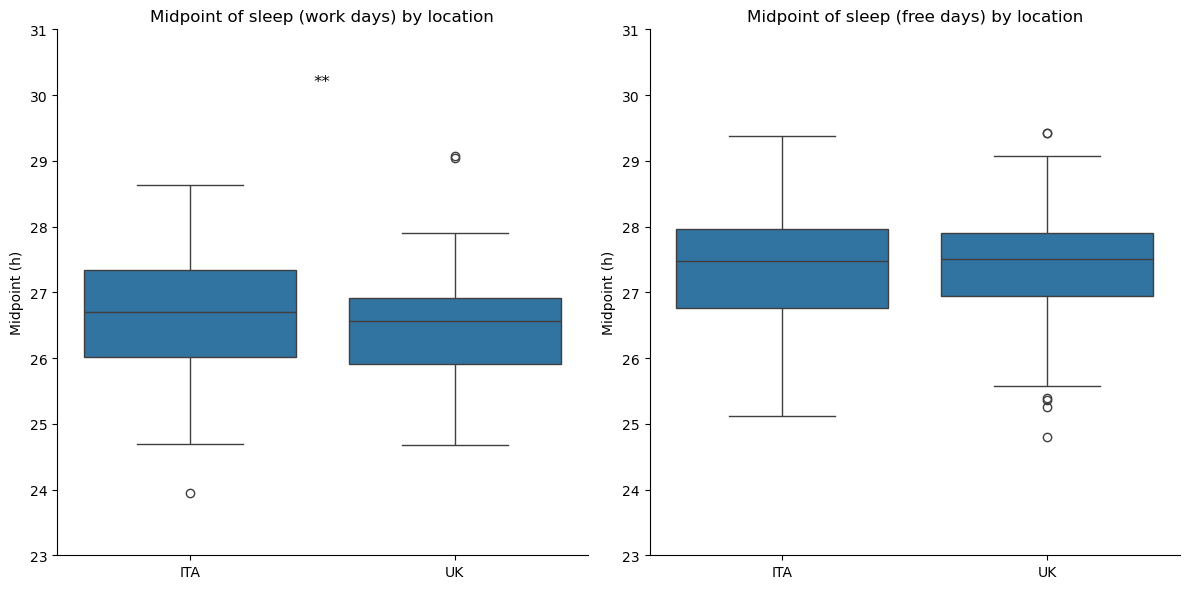

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x='location', y='midpoint_h', data=df_workdays, ax=ax[0])
ax[0].set_title('Midpoint of sleep (work days) by location')
ax[0].set_ylabel('Midpoint (h)')
ax[0].set_xlabel('')
ax[0].yaxis.set_major_locator(MultipleLocator(1))
ax[0].set_ylim(23, 31)
#add a significance line of ** for the p-value < 0.01
if ttest_midpoint_workdays_loc.pvalue < 0.01:
    ax[0].annotate('**', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) 

sns.boxplot(x='location', y='midpoint_h', data=df_freedays, ax=ax[1])
ax[1].set_title('Midpoint of sleep (free days) by location')
ax[1].set_ylabel('Midpoint (h)')
ax[1].set_xlabel('')
ax[1].yaxis.set_major_locator(MultipleLocator(1))
ax[1].set_ylim(ax[0].get_ylim())

#add a significance line of  for the p-value < 0.05
if ttest_midpoint_freedays_loc.pvalue < 0.05:
    ax[1].annotate('', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) 
    
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.tight_layout()
plt.show()

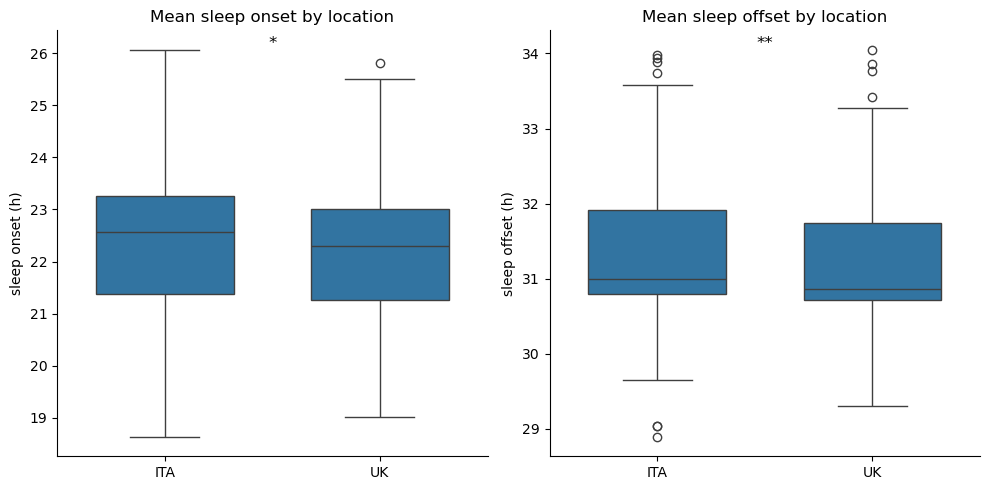

In [29]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='sleep_start_decimal', data=df, gap=0.2)
plt.title("Mean sleep onset by location")
plt.xlabel("")
plt.ylabel("sleep onset (h)")
#add a significance line to the subplot
if utest_start_loc.pvalue < 0.05:
    plt.annotate('*', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(x='location', y='sleep_end_decimal', data=df, gap=0.2)
plt.title("Mean sleep offset by location")
plt.xlabel("")
plt.ylabel("sleep offset (h)")
#add a significance line 
if utest_end_loc.pvalue < 0.01:
    plt.annotate('**', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

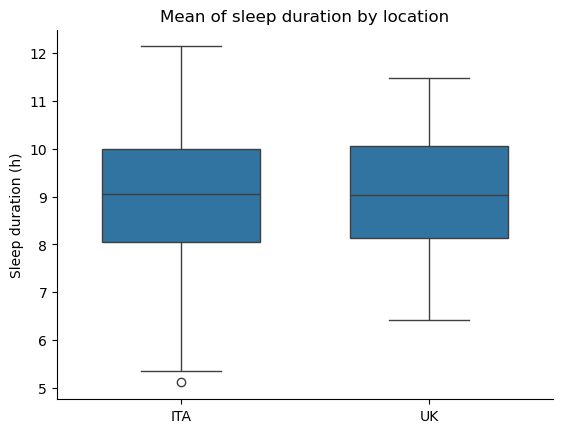

In [30]:
plt.figure()
sns.boxplot(x='location', y='sleep_duration(h)', data=df, gap=0.2)
plt.title('Mean of sleep duration by location')
plt.xlabel('')
plt.ylabel('Sleep duration (h)')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.show()

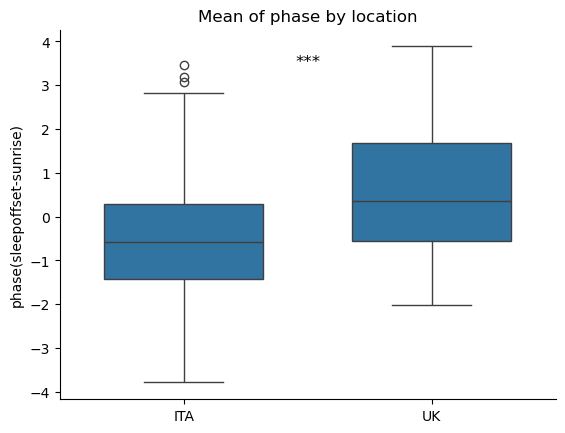

In [31]:
plt.figure()
sns.boxplot(x='location', y='phase(sleepoffset-sunrise)', data=df, gap=0.2)
plt.title('Mean of phase by location')
plt.xlabel('')
plt.ylabel('phase(sleepoffset-sunrise)')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')

#add a significance line 
if utest_phase_loc.pvalue < 0.001:
    plt.annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', fontsize=12)
plt.show()

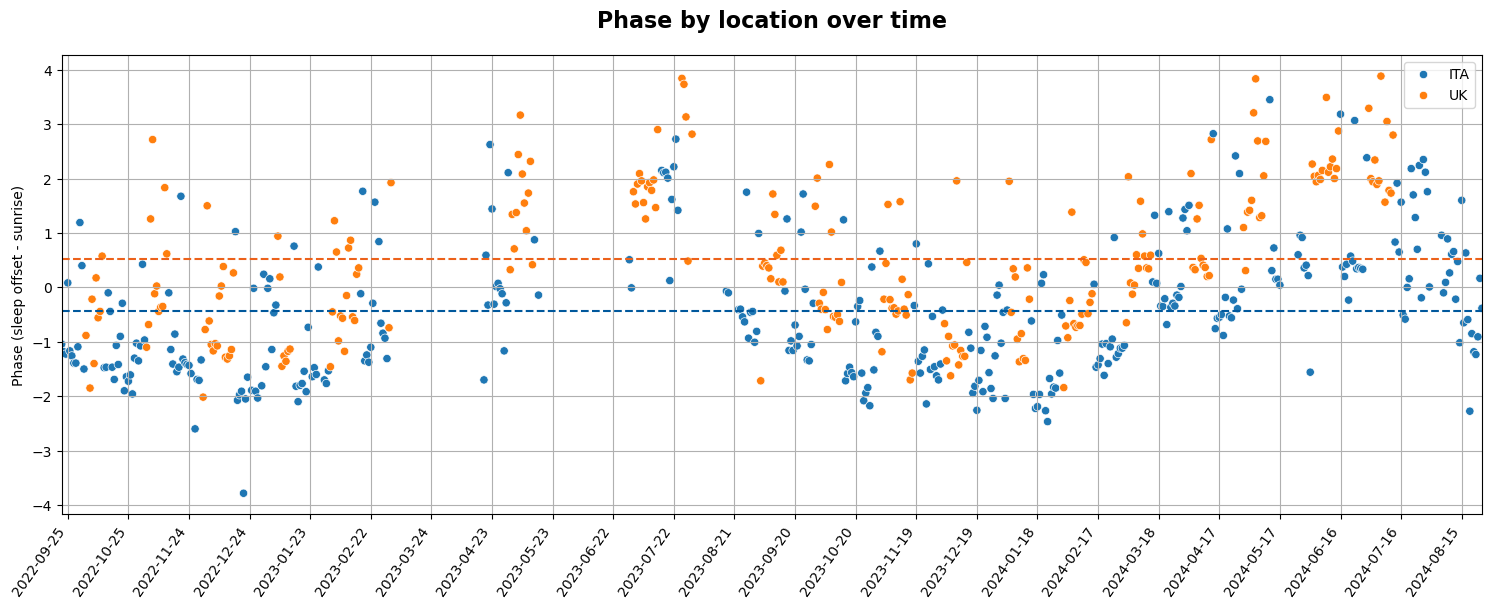

In [32]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase(sleepoffset-sunrise)', hue='location', data=df)
plt.title('Phase by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (sleep offset - sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())

# get the current axes then set the x-axis major locator
# plot.gca()=ax if set ax = plt.gca()
plt.gca().xaxis.set_major_locator(MultipleLocator(30)) 

#add the mean of the phase for the two locations
plt.axhline(df[df['location'] == 'ITA']['phase(sleepoffset-sunrise)'].mean(), color='#00589c', linestyle='--', label='ITA mean')
plt.axhline(df[df['location'] == 'UK']['phase(sleepoffset-sunrise)'].mean(), color='#ec611a', linestyle='--', label='UK mean')

plt.show()

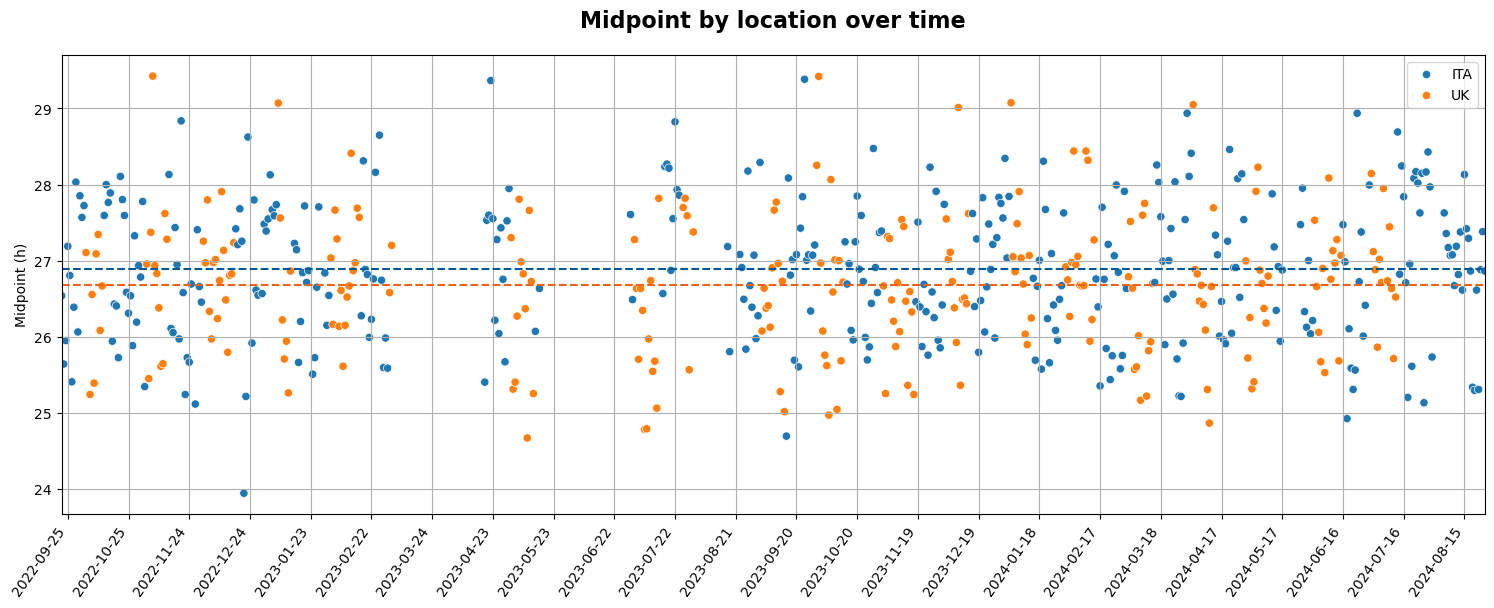

In [33]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='midpoint_h', hue='location', data=df)
plt.title('Midpoint by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midpoint (h)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())

# get the current axes then set the x-axis major locator
# plot.gca()=ax if set ax = plt.gca()
plt.gca().xaxis.set_major_locator(MultipleLocator(30)) 

#add the mean of the phase for the two locations
plt.axhline(df[df['location'] == 'ITA']['midpoint_h'].mean(), color='#00589c', linestyle='--', label='ITA mean')
plt.axhline(df[df['location'] == 'UK']['midpoint_h'].mean(), color='#ec611a', linestyle='--', label='UK mean')

plt.show()

_Jetlag_

In [34]:
data_jetlag = df # create a new dataframe with the original data

In [35]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag = data_jetlag.groupby(['location', 'week_of_year', 'weekday_type'])['midpoint_h'].mean().unstack()

In [36]:
weekly_means_jetlag['jet lag'] = weekly_means_jetlag['free days'] - weekly_means_jetlag['work days']

In [37]:
# add a column with the location
weekly_means_jetlag['location'] = weekly_means_jetlag.index.get_level_values(0)

In [38]:
#save the data to a csv file
weekly_means_jetlag.to_csv(fpath + '\\weekly_means_jetlag.csv')

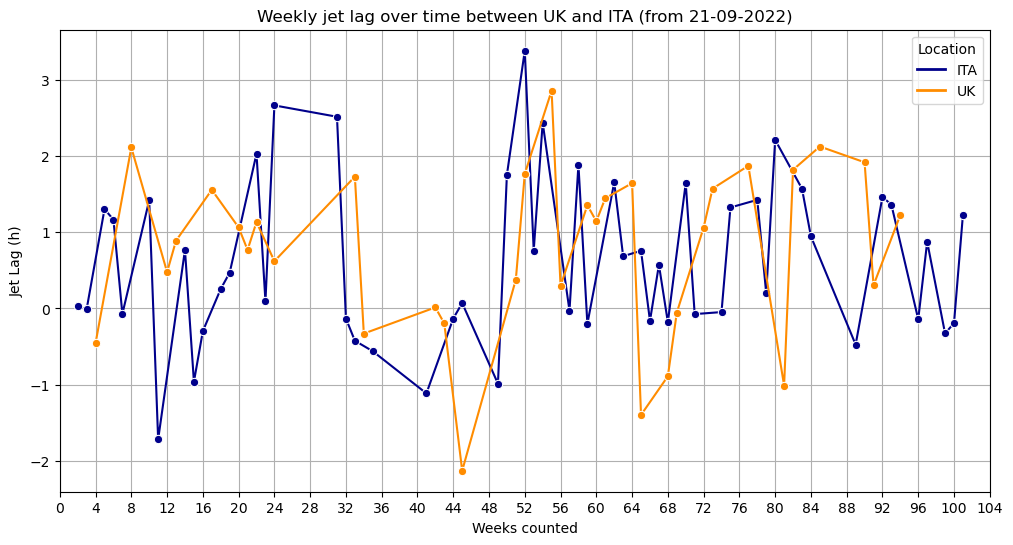

In [39]:
# Plot the weekly jet lag between UK and ITA
plt.figure(figsize=(12, 6))
sns.lineplot(x='week_of_year', y='jet lag', hue='location', data=weekly_means_jetlag, marker='o', palette=['darkblue', 'darkorange'])
plt.title('Weekly jet lag over time between UK and ITA (from 21-09-2022)')
plt.xlabel('Weeks counted')
plt.ylabel('Jet Lag (h)')
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange', lw=2)])
plt.grid(True)
plt.xlim(0, 104)
plt.gca().xaxis.set_major_locator(MultipleLocator(4)) 
plt.xticks()
plt.show()

In [40]:
# Remove NaN values before performing the Shapiro-Wilk test
jetlag_no_nan = weekly_means_jetlag['jet lag'].dropna()

In [41]:
# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_no_nan)

In [42]:
shapiro_test_jetlag

ShapiroResult(statistic=0.9886062153387764, pvalue=0.6513971208853703)

In [43]:
# Perform a t-test to compare the jet lag between the two locations
ttest_jetlag = stats.ttest_ind(weekly_means_jetlag[weekly_means_jetlag['location'] == 'ITA']['jet lag'].dropna(), weekly_means_jetlag[weekly_means_jetlag['location'] == 'UK']['jet lag'].dropna())

In [44]:
print('Results for jet lag:')
print(ttest_jetlag)

Results for jet lag:
TtestResult(statistic=-0.6990671681442698, pvalue=0.48641855739690765, df=85.0)


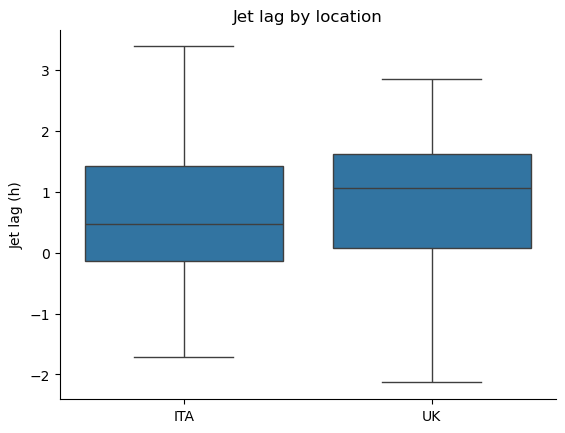

In [45]:
# plot the jet lag
plt.figure()
sns.boxplot(x='location', y='jet lag', data=weekly_means_jetlag)
plt.title('Jet lag by location')
plt.xlabel('')
plt.ylabel('Jet lag (h)')

sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

plt.show()

_Seasonal effect_

In [46]:
df = df.rename(columns={'sleep_duration(h)': 'sleep_duration'})

In [47]:
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})

In [48]:
# Adding a 'season' column to the dataset based on the 'date' column
# Defining seasons based on months: 
# Winter (Dec-Feb), Spring (Mar-May), Summer (Jun-Aug), Autumn (Sep-Nov)

def assign_season(date):
    month = pd.to_datetime(date).month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

In [49]:
# Applying the function to create a season column
df_workdays['season'] = df_workdays['date'].apply(assign_season)
df_freedays['season'] = df_freedays['date'].apply(assign_season)
df['season'] = df['date'].apply(assign_season)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_16360\2974399819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays['season'] = df_workdays['date'].apply(assign_season)
C:\Users\gg00642\AppData\Local\Temp\ipykernel_16360\2974399819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays['season'] = df_freedays['date'].apply(assign_season)


In [50]:
df = df.dropna(subset=['sleep_duration'])
df = df.dropna(subset=['phase'])

In [51]:
anova_midpoint_work_season1 = ols('midpoint_h ~ C(season)', data=df_workdays).fit()

In [52]:
anova_midpoint_free_season1 = ols('midpoint_h ~ C(season)', data=df_freedays).fit()

In [53]:
anova_midpoint_work_result_season1 = sm.stats.anova_lm(anova_midpoint_work_season1, typ=3) #fit the ANOVA model and get the results

In [54]:
anova_midpoint_free_result_season1 = sm.stats.anova_lm(anova_midpoint_free_season1, typ=3)

In [55]:
print("\nANOVA_midpoint work Results:")
print(anova_midpoint_work_result_season1)
print("\nANOVA_midpoint free Results:")
print(anova_midpoint_free_result_season1)


ANOVA_midpoint work Results:
                 sum_sq     df              F    PR(>F)
Intercept  79677.117208    1.0  119166.984321  0.000000
C(season)      7.303085    3.0       3.640889  0.012908
Residual     271.458658  406.0            NaN       NaN

ANOVA_midpoint free Results:
                 sum_sq     df             F         PR(>F)
Intercept  33804.524727    1.0  38718.612960  6.452900e-184
C(season)      1.136007    3.0      0.433715   7.291694e-01
Residual     131.835385  151.0           NaN            NaN


In [56]:
# Kruskal-Wallis test 
kw_sleep_duration_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_duration'], df[df['season'] == 'Spring']['sleep_duration'], df[df['season'] == 'Summer']['sleep_duration'], df[df['season'] == 'Autumn']['sleep_duration'])
kw_phase_season = stats.kruskal(df[df['season'] == 'Winter']['phase'], df[df['season'] == 'Spring']['phase'], df[df['season'] == 'Summer']['phase'], df[df['season'] == 'Autumn']['phase'])
kw_start_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_start_decimal'], df[df['season'] == 'Spring']['sleep_start_decimal'], df[df['season'] == 'Summer']['sleep_start_decimal'], df[df['season'] == 'Autumn']['sleep_start_decimal'])
kw_end_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_end_decimal'], df[df['season'] == 'Spring']['sleep_end_decimal'], df[df['season'] == 'Summer']['sleep_end_decimal'], df[df['season'] == 'Autumn']['sleep_end_decimal'])

In [57]:
print('Results for Kruskal-Wallis test for the sleep duration by season')
print(kw_sleep_duration_season)
print('Results for Kruskal-Wallis test for the phase by season')
print(kw_phase_season)
print('Results for Kruskal-Wallis test for the sleep onset by season')
print(kw_start_season)
print('Results for Kruskal-Wallis test for the sleep offset by season')
print(kw_end_season)

Results for Kruskal-Wallis test for the sleep duration by season
KruskalResult(statistic=1.5890340956216034, pvalue=0.6618788132777524)
Results for Kruskal-Wallis test for the phase by season
KruskalResult(statistic=203.3077922242939, pvalue=8.136011047815583e-44)
Results for Kruskal-Wallis test for the sleep onset by season
KruskalResult(statistic=5.621276836102977, pvalue=0.1315622004309528)
Results for Kruskal-Wallis test for the sleep offset by season
KruskalResult(statistic=1.7633590418476661, pvalue=0.6229406896119625)


In [58]:
# perform a Tukey HSD test to compare the means
tukey_results_season1 = pairwise_tukeyhsd(df_workdays['midpoint_h'], df_workdays['season'])
print(tukey_results_season1)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.0414 0.9852  -0.263 0.3457  False
Autumn Summer    0.312 0.0391  0.0107 0.6133   True
Autumn Winter    0.259 0.0687 -0.0132 0.5311  False
Spring Summer   0.2706  0.139  -0.054 0.5952  False
Spring Winter   0.2176 0.2359 -0.0801 0.5153  False
Summer Winter   -0.053 0.9668 -0.3476 0.2416  False
---------------------------------------------------


In [59]:
# Perform a Tukey HSD test to compare the means
tukey_results_season4 = pairwise_tukeyhsd(df['phase'], df['season'])
print(tukey_results_season4)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring   1.2441    0.0  0.8949  1.5933   True
Autumn Summer   1.7125    0.0  1.3668  2.0583   True
Autumn Winter  -0.2876 0.0834 -0.5997  0.0246  False
Spring Summer   0.4685 0.0071  0.0948  0.8421   True
Spring Winter  -1.5316    0.0 -1.8745 -1.1888   True
Summer Winter  -2.0001    0.0 -2.3394 -1.6608   True
----------------------------------------------------


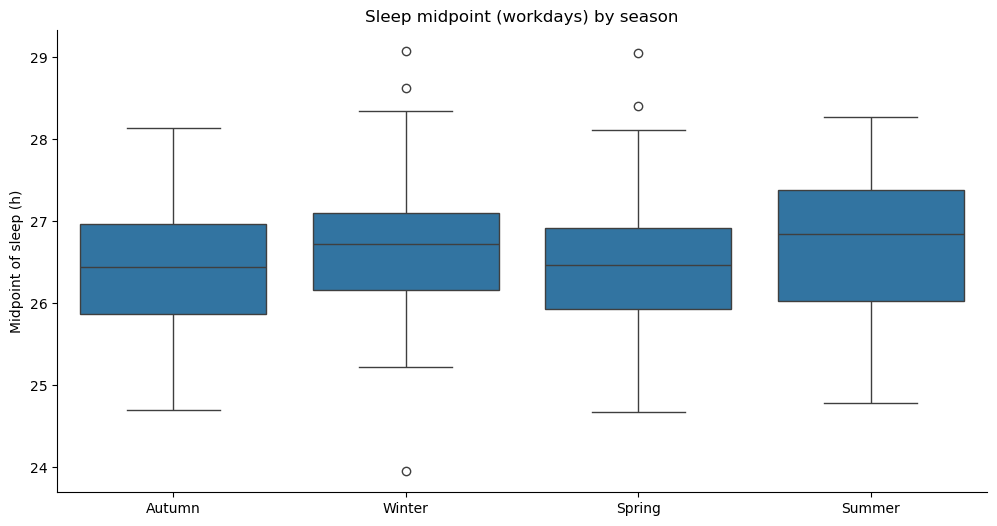

In [60]:
# Sleep Midpoint (work) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='midpoint_h', data=df_workdays)
plt.title('Sleep midpoint (workdays) by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midpoint of sleep (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
#bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

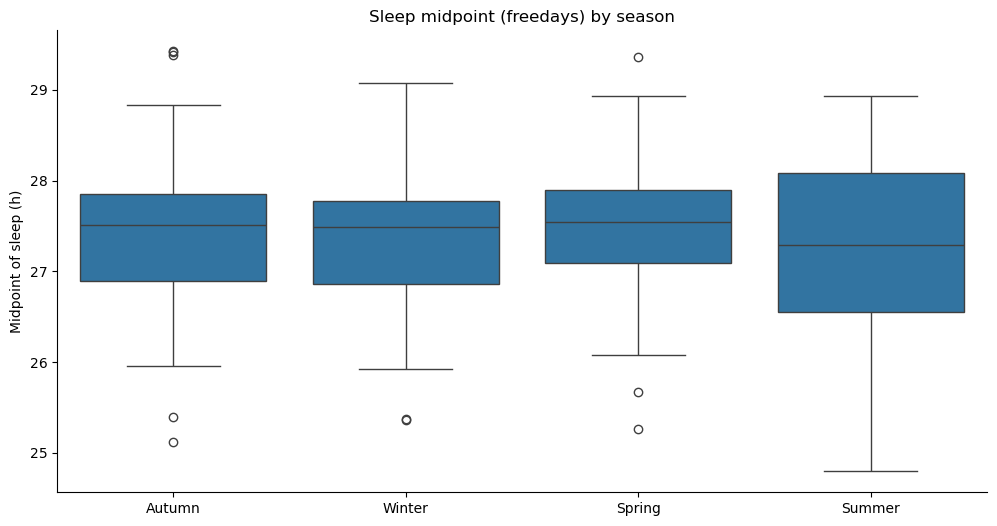

In [61]:
# Sleep Midpoint (free) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='midpoint_h', data=df_freedays)
plt.title('Sleep midpoint (freedays) by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midpoint of sleep (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

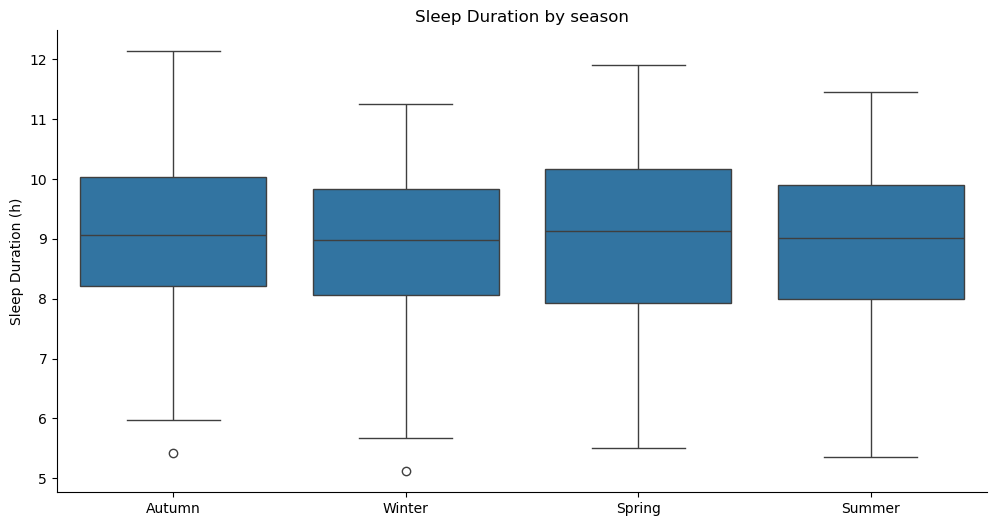

In [62]:
# Sleep Duration by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='sleep_duration', data=df)
plt.title('Sleep Duration by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Sleep Duration (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

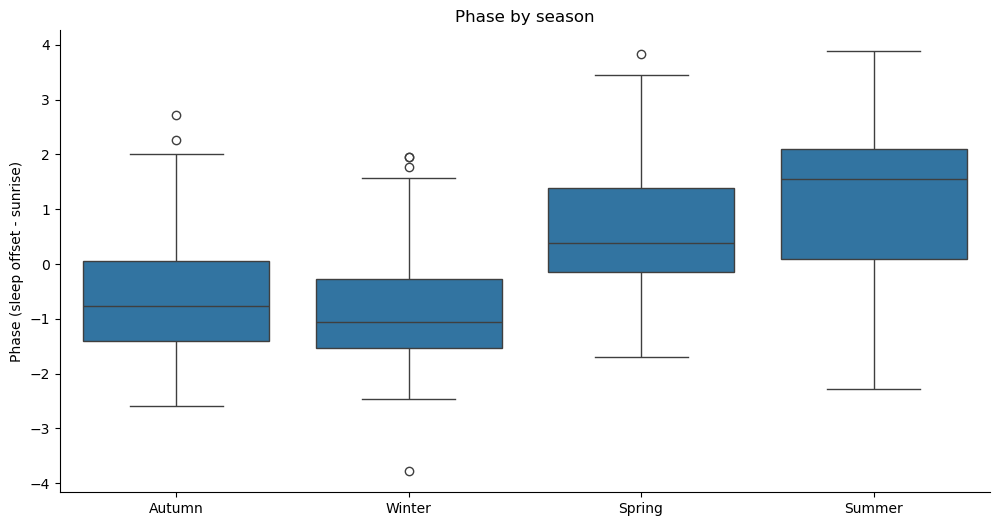

In [63]:
# Sleep Phase by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='phase', data=df)
plt.title('Phase by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (sleep offset - sunrise)')
plt.xlabel('')
sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

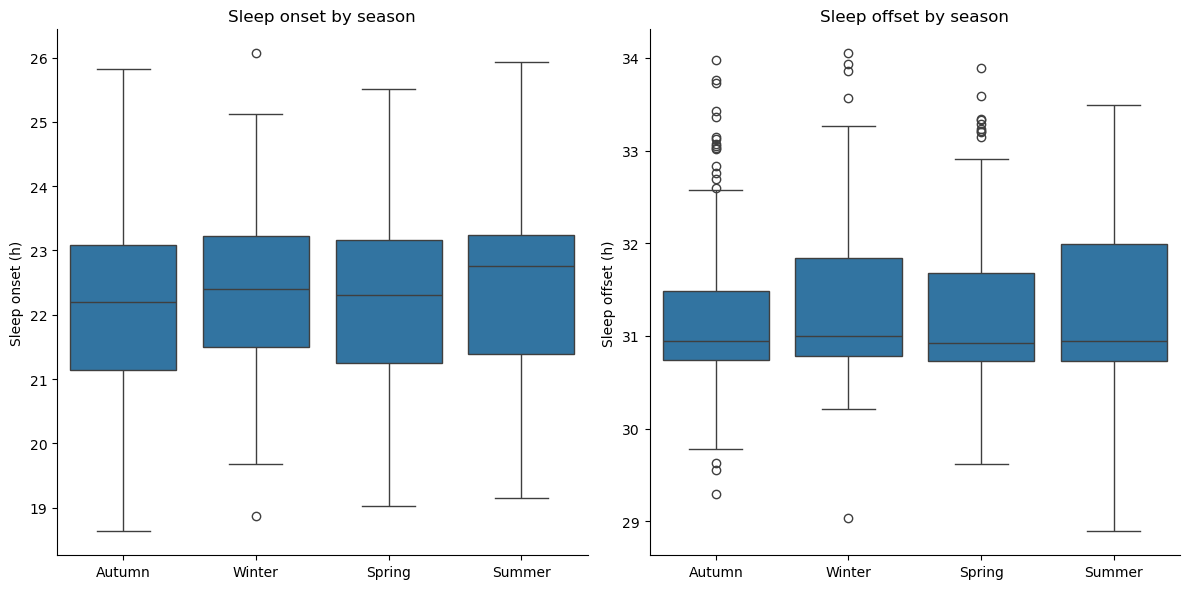

In [64]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='season', y='sleep_start_decimal', data=df)
plt.title('Sleep onset by season')
plt.ylabel('Sleep onset (h)')
plt.xlabel('')

plt.subplot(1, 2, 2)
sns.boxplot(x='season', y='sleep_end_decimal', data=df)
plt.title('Sleep offset by season')
plt.ylabel('Sleep offset (h)')
plt.xlabel('')

# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

_Photoperiod and sleep-wake pattern_

In [65]:
# if column 'location' = 1 take the value from 'photoperiod (h, UK)' 
# if column 'location' = 0 then photoperiod (h, ITA)'
df['photoperiod'] = np.where(df['location'] == 'UK', df['photoperiod (h, UK)'], df['photoperiod (h, ITA)'])

In [66]:
df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)']
df_workdays.loc[df_workdays['location'] == 'ITA', 'photoperiod'] = df_workdays['photoperiod (h, ITA)']

df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']
df_freedays.loc[df_freedays['location'] == 'ITA', 'photoperiod'] = df_freedays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_16360\2750541235.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)']
C:\Users\gg00642\AppData\Local\Temp\ipykernel_16360\2750541235.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']


In [67]:
correlation_test1 = stats.pearsonr(df_workdays['midpoint_h'], df_workdays['photoperiod'])
correlation_test2 = stats.pearsonr(df_freedays['midpoint_h'], df_freedays['photoperiod'])
correlation_test3 = stats.spearmanr(df['sleep_start_decimal'], df['photoperiod'])
correlation_test4 = stats.spearmanr(df['sleep_end_decimal'], df['photoperiod'])

In [68]:
# Extract the coefficients and p-values from the correlation test results
pearson_coeff = [correlation_test1.statistic, correlation_test2.statistic, correlation_test3.statistic, correlation_test4.statistic]
p_values = [correlation_test1.pvalue, correlation_test2.pvalue, correlation_test3.pvalue, correlation_test4.pvalue]

# Create a DataFrame with the results
correlation_results = pd.DataFrame({
    'Variables': ['midpoint (work) vs photoperiod', 'midpoint (free) vs photoperiod', 'sleep onset vs photoperiod', 'sleep offset vs photoperiod'],
    'Coefficient': pearson_coeff,
    'P-value': p_values
})

correlation_results

,Variables,Coefficient,P-value
0,midpoint (work) vs photoperiod,0.010758,0.828071
1,midpoint (free) vs photoperiod,-0.026400,0.744369
2,sleep onset vs photoperiod,0.024123,0.567187
3,sleep offset vs photoperiod,-0.036483,0.386730


_Phase by location, time and photoperiod_

In [69]:
data_phase = df.dropna(subset=['phase', 'location', 'date', 'photoperiod'])

In [70]:
data_phase['location'] = data_phase['location'].map({'ITA': 0, 'UK': 1})

In [71]:
# Converting date to numerical values (days since the start of the observation period)
data_phase['date_numeric'] = (pd.to_datetime(data_phase['date']) - pd.to_datetime(data_phase['date']).min()).dt.days

In [72]:
glm_model_phase_numeric1 = smf.glm(
    formula="phase ~ location + date_numeric ",
    data=data_phase,
    family=sm.families.Gaussian()
)

In [73]:
# Fit of the model
glm_results_phase_numeric1 = glm_model_phase_numeric1.fit()

In [74]:
# Output the summary of the model
glm_results_phase_numeric_summary1 = glm_results_phase_numeric1.summary()
glm_results_phase_numeric_summary1

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  phase   No. Observations:                  565
Model:                            GLM   Df Residuals:                      562
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          1.4737
Method:                          IRLS   Log-Likelihood:                -909.75
Date:                Fri, 01 Nov 2024   Deviance:                       828.24
Time:                        15:59:25   Pearson chi2:                     828.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2503
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.2292      0.112    -10.993      0.000      -1.448      -1.010
location         0.9844      0.104      9.467      0.000       0.781       1.188
date_numeric     0.0021      0.000      8.764      0.000       0.002       0.003
================================================================================
"""

In [75]:
glm_model_phase_numeric2 = smf.glm(
    formula="phase ~ location + date_numeric + photoperiod",
    data=data_phase,
    family=sm.families.Gaussian()
)

In [76]:
# Fit of the model
glm_results_phase_numeric2 = glm_model_phase_numeric2.fit()

In [77]:
# Output the summary of the model
glm_results_phase_numeric_summary2 = glm_results_phase_numeric2.summary()
glm_results_phase_numeric_summary2

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  phase   No. Observations:                  565
Model:                            GLM   Df Residuals:                      561
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                         0.87887
Method:                          IRLS   Log-Likelihood:                -763.22
Date:                Fri, 01 Nov 2024   Deviance:                       493.05
Time:                        15:59:25   Pearson chi2:                     493.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.6859
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -4.3579      0.182    -23.945      0.000      -4.715      -4.001
location         0.9874      0.080     12.296      0.000       0.830       1.145
date_numeric     0.0002      0.000      0.911      0.362      -0.000       0.001
photoperiod      0.3263      0.017     19.529      0.000       0.294       0.359
================================================================================
"""

_Midpoint by location and week day_

In [78]:
model_1 = ols('midpoint_h ~ C(location) * C(weekday_type)', data=df).fit() # C() is used to indicate categorical variables

In [79]:
anova_results = sm.stats.anova_lm(model_1, typ=3)

In [80]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                                   sum_sq     df             F        PR(>F)
Intercept                    71090.857907    1.0  98545.463270  0.000000e+00
C(location)                      0.000713    1.0      0.000989  9.749257e-01
C(weekday_type)                 29.125550    1.0     40.373558  4.342691e-10
C(location):C(weekday_type)      1.959224    1.0      2.715858  9.991545e-02
Residual                       404.706315  561.0           NaN           NaN


In [81]:
# regression coefficients of the model (ita work days as the reference)
weights = model_1.params / model_1.params.abs().sum()
weights

Intercept                                         0.967166
C(location)[T.UK]                                 0.000156
C(weekday_type)[T.work days]                     -0.023129
C(location)[T.UK]:C(weekday_type)[T.work days]   -0.009550
dtype: float64

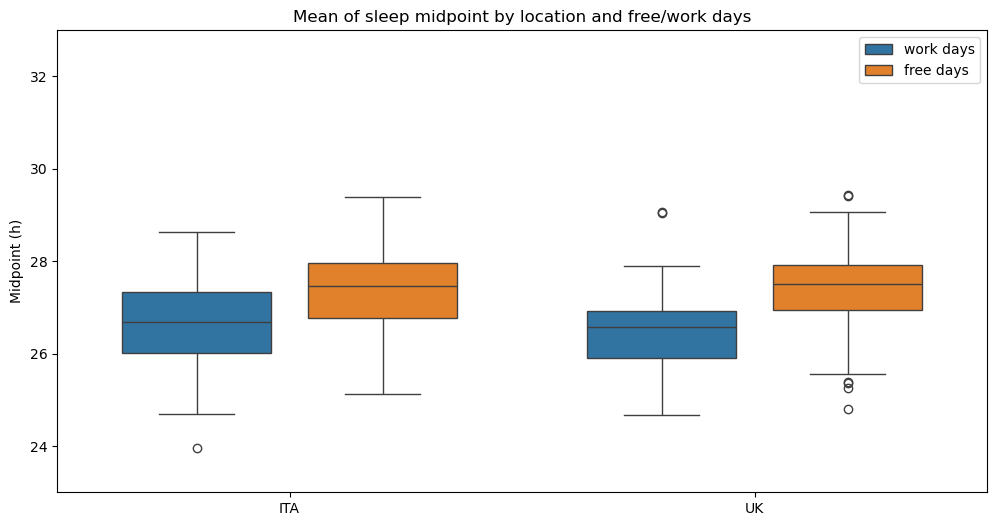

In [82]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='midpoint_h', hue='weekday_type', data=df, gap=0.2)
plt.title('Mean of sleep midpoint by location and free/work days')
plt.xlabel('')
plt.ylim(23, 33)
plt.ylabel('Midpoint (h)')
plt.legend()
plt.show()

In [83]:
model_work = smf.ols('midpoint_h ~ C(location) * photoperiod', data=df_workdays).fit()

In [84]:
model_work.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             midpoint_h   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     4.052
Date:                Fri, 01 Nov 2024   Prob (F-statistic):            0.00741
Time:                        15:59:25   Log-Likelihood:                -496.63
No. Observations:                 410   AIC:                             1001.
Df Residuals:                     406   BIC:                             1017.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        26.4032      0.271     97.261      0.000      25.870      26.937
C(location)[T.UK]                 0.1751      0.366      0.479      0.632      -0.544       0.894
photoperiod                       0.0254      0.023      1.119      0.264      -0.019       0.070
C(location)[T.UK]:photoperiod    -0.0375      0.030     -1.239      0.216      -0.097       0.022
==============================================================================
Omnibus:                        0.255   Durbin-Watson:                   1.630
Prob(Omnibus):                  0.880   Jarque-Bera (JB):                0.375
Skew:                           0.028   Prob(JB):                        0.829
Kurtosis:                       2.863   Cond. No.                         143.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [85]:
model_free = smf.ols('midpoint_h ~ C(location) * photoperiod', data=df_freedays).fit()

In [86]:
model_free.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             midpoint_h   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.204
Date:                Fri, 01 Nov 2024   Prob (F-statistic):              0.310
Time:                        15:59:26   Log-Likelihood:                -206.22
No. Observations:                 155   AIC:                             420.4
Df Residuals:                     151   BIC:                             432.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        26.8238      0.493     54.364      0.000      25.849      27.799
C(location)[T.UK]                 1.2465      0.684      1.823      0.070      -0.105       2.598
photoperiod                       0.0446      0.041      1.098      0.274      -0.036       0.125
C(location)[T.UK]:photoperiod    -0.1070      0.057     -1.872      0.063      -0.220       0.006
==============================================================================
Omnibus:                        2.199   Durbin-Watson:                   1.960
Prob(Omnibus):                  0.333   Jarque-Bera (JB):                2.192
Skew:                          -0.283   Prob(JB):                        0.334
Kurtosis:                       2.866   Cond. No.                         139.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

_Phase by location and week day_

In [87]:
data_phase2 = df.dropna(subset=['phase', 'location', 'weekday_type'])

In [88]:
glm_model_phase2 = smf.glm(
    formula="phase ~ location + weekday_type",
    data=data_phase2,
    family=sm.families.Gaussian()
)

In [89]:
# Fit of the model
glm_results_phase2 = glm_model_phase2.fit()

In [90]:
# Output the summary of the model (ita and free days as baseline)
glm_results_phase2_summary = glm_results_phase2.summary()
glm_results_phase2_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  phase   No. Observations:                  565
Model:                            GLM   Df Residuals:                      562
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          1.5033
Method:                          IRLS   Log-Likelihood:                -915.35
Date:                Fri, 01 Nov 2024   Deviance:                       844.83
Time:                        15:59:26   Pearson chi2:                     845.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2312
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.2238      0.107      2.100      0.036       0.015       0.433
location[T.UK]                0.9849      0.105      9.378      0.000       0.779       1.191
weekday_type[T.work days]    -0.9270      0.116     -8.016      0.000      -1.154      -0.700
=============================================================================================
"""

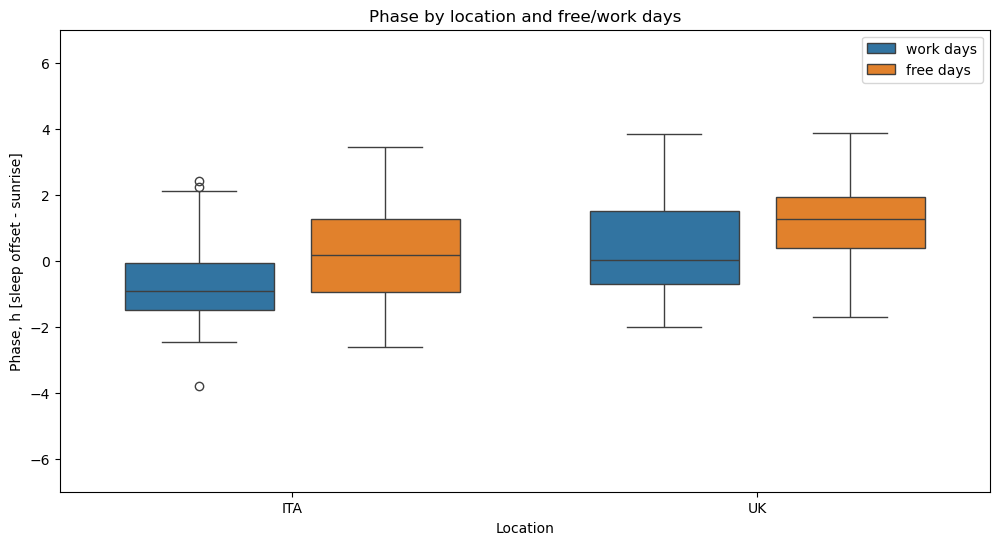

In [91]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='phase', hue='weekday_type', data=data_phase2, gap=0.2)
plt.title('Phase by location and free/work days')
plt.xlabel('Location')
plt.ylim(-7,7)
plt.ylabel('Phase, h [sleep offset - sunrise]')
plt.legend()

plt.show()

_Weekly IV, IS and RA_

In [92]:
# Load the datasets
weekly_values = pd.read_csv(fpath + '\\weekly_IV_IS_RA_values_with_dates.csv')
weekly_jetlag = weekly_means_jetlag

In [93]:
# Split Date_Range into Start_Date and End_Date in weekly_values
weekly_values[['Start_Date', 'End_Date']] = weekly_values['Date_Range'].str.split(' to ', expand=True)

In [94]:
# Convert Start_Date and End_Date to datetime format
weekly_values['Start_Date'] = pd.to_datetime(weekly_values['Start_Date'])
weekly_values['End_Date'] = pd.to_datetime(weekly_values['End_Date'])

In [95]:
# Merge by matching the week number extracted from Start_Date with week_of_year in weekly_jetlag
merged_data = pd.merge(
    weekly_values,
    weekly_jetlag,
    left_on=weekly_values['Start_Date'].dt.isocalendar().week,
    right_on='week_of_year',
    how='inner'
)

merged_data.head()

,week_of_year,Date_Range,IS,IV,RA,Start_Date,End_Date,free days,work days,jet lag,location
0,41,2022-10-12 to 2022-10-18,0.593843,0.089441,0.945319,2022-10-12,2022-10-18,26.491667,27.608333,-1.116667,ITA
1,42,2022-10-19 to 2022-10-25,0.592888,0.086393,0.934961,2022-10-19,2022-10-25,26.037500,26.024167,0.013333,UK
2,43,2022-10-26 to 2022-11-01,0.615197,0.086685,0.958284,2022-10-26,2022-11-01,25.975000,26.172500,-0.197500,UK
3,44,2022-11-02 to 2022-11-08,0.552785,0.081076,0.911548,2022-11-02,2022-11-08,27.697917,27.830833,-0.132917,ITA
4,45,2022-11-09 to 2022-11-15,0.555176,0.070588,0.944386,2022-11-09,2022-11-15,27.933333,27.862500,0.070833,ITA


In [96]:
# Summary statistics
summary_stats = merged_data.groupby("location")[['IV', 'IS', 'RA']].describe()
summary_stats

IV                                                              \
         count      mean       std       min       25%       50%       75%   
location                                                                     
ITA       51.0  0.078998  0.021793  0.024172  0.067675  0.081076  0.090757   
UK        36.0  0.088097  0.020323  0.040270  0.075134  0.086539  0.099973   

                      IS            ...                        RA            \
               max count      mean  ...       75%       max count      mean   
location                            ...                                       
ITA       0.130562  51.0  0.523448  ...  0.604193  0.647358  50.0  0.934366   
UK        0.130562  36.0  0.537676  ...  0.614306  0.645810  36.0  0.917165   

                                                                      
               std       min       25%       50%       75%       max  
location                                                              
ITA       0.070674  0.480668  0.932392  0.941753  0.949313  1.097278  
UK        0.091460  0.480668  0.922486  0.940388  0.947696  0.964346  

[2 rows x 24 columns]

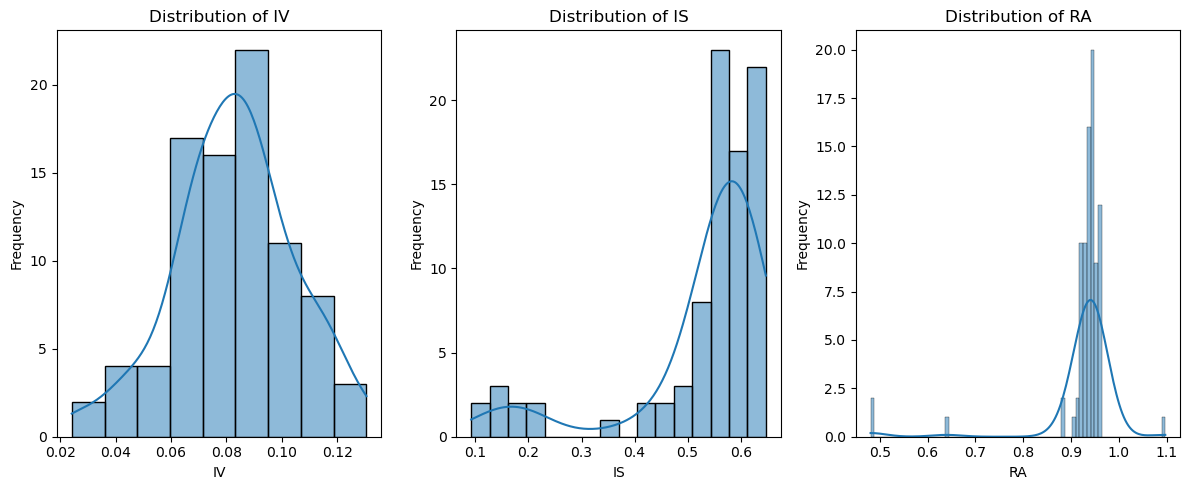

In [97]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.histplot(merged_data['IV'].dropna(), kde=True)
plt.title("Distribution of IV")
plt.xlabel("IV")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(merged_data['IS'].dropna(), kde=True)
plt.title('Distribution of IS')
plt.xlabel('IS')
plt.ylabel('Frequency')
 
plt.subplot(1, 3, 3)
sns.histplot(merged_data['RA'].dropna(), kde=True)
plt.title("Distribution of RA")
plt.xlabel("RA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [98]:
iv_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['IV'], merged_data[merged_data['location'] == 'UK']['IV'], nan_policy='omit')
is_ttest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['IS'], merged_data[merged_data['location'] == 'UK']['IS'], nan_policy='omit')
ra_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['RA'], merged_data[merged_data['location'] == 'UK']['RA'], nan_policy='omit')

In [99]:
print("\nT-test results for IV by Location:", iv_ttest)
print("U-test results for IS by Location:", is_ttest)
print("T-test results for RA by Location:", ra_ttest)


T-test results for IV by Location: TtestResult(statistic=-1.9715074953727594, pvalue=0.05191870528148813, df=85.0)
U-test results for IS by Location: MannwhitneyuResult(statistic=897.0, pvalue=0.8597536798194605)
T-test results for RA by Location: TtestResult(statistic=0.9837280409171583, pvalue=0.32807424964869647, df=84.0)


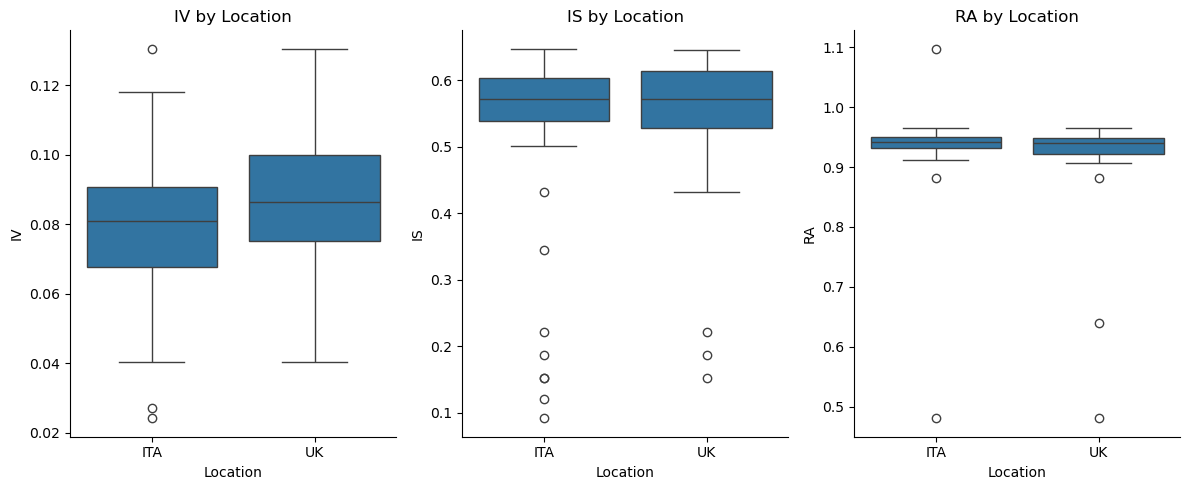

In [100]:
plt.figure(figsize=(12, 5))

# IV by Location
plt.subplot(1, 3, 1)
sns.boxplot(x="location", y="IV", data=merged_data)
plt.title("IV by Location")
plt.xlabel("Location")
plt.ylabel("IV")

# IS by Location
plt.subplot(1, 3, 2)
sns.boxplot(x="location", y="IS", data=merged_data)
plt.title("IS by Location")
plt.xlabel("Location")
plt.ylabel("IS")

plt.subplot(1, 3, 3)
sns.boxplot(x="location", y="RA", data=merged_data)
plt.title("RA by Location")
plt.xlabel("Location")
plt.ylabel("RA")

sns.despine()
plt.tight_layout()
plt.show()